In [107]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [108]:
data_path = r"D:\Data Science and Machine Learning\ML and GenAI Projects\Car Price Prediction\data\sample_vehicle.csv"

In [109]:
df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,385568,7301987654,https://wichitafalls.craigslist.org/ctd/d/wich...,wichita falls,https://wichitafalls.craigslist.org,38590,2020.0,bmw,3 series 330i xdrive sedan,good,NaN,gas,5580.0,clean,other,WBA5R7C09LFH33987,NaN,NaN,sedan,black,https://images.craigslist.org/00M0M_5PEtp5wnK6...,Carvana is the safer way to buy a car During t...,NaN,tx,33.890000,-98.510000,2021-04-05T07:52:45-0500
1,82318,7310604775,https://westslope.craigslist.org/ctd/d/grand-j...,western slope,https://westslope.craigslist.org,21995,2014.0,ram,2500 slt 4x4,NaN,8 cylinders,gas,146725.0,clean,automatic,3C6TR5DTXEG122945,4wd,NaN,pickup,white,https://images.craigslist.org/00n0n_5JgrqJrBq8...,2014 Ram 2500 SLT 4X4 TruckExterior Color: Br...,NaN,co,39.093933,-108.611602,2021-04-21T16:51:42-0600
2,44903,7310818650,https://palmsprings.craigslist.org/ctd/d/palm-...,palm springs,https://palmsprings.craigslist.org,0,2012.0,chevrolet,volt,NaN,NaN,electric,86490.0,clean,automatic,1G1RD6E47CU113847,fwd,NaN,hatchback,NaN,https://images.craigslist.org/00R0R_1oYg5bdxI7...,Coachella Valley Volkswagen STOCK #: T...,NaN,ca,33.755638,-116.286258,2021-04-22T07:30:41-0700
3,307507,7301875684,https://stillwater.craigslist.org/cto/d/stillw...,stillwater,https://stillwater.craigslist.org,9500,2011.0,kia,optima,good,4 cylinders,gas,87800.0,clean,automatic,KNAGN4A73B5117304,fwd,full-size,sedan,black,https://images.craigslist.org/00C0C_5I8rZZ1DGC...,Only two total owners Only selling the car bec...,NaN,ok,36.104300,-97.060900,2021-04-04T19:41:11-0500
4,251229,7309995060,https://cnj.craigslist.org/ctd/d/farmingdale-2...,central NJ,https://cnj.craigslist.org,73495,2019.0,lincoln,navigator l,NaN,NaN,gas,8180.0,clean,automatic,5LMJJ3LT5KEL20180,NaN,NaN,NaN,NaN,https://images.craigslist.org/00M0M_3XsPjkbjvG...,2019 Lincoln Navigator L CALL Automotive Avenu...,NaN,nj,40.204300,-74.177900,2021-04-20T15:53:11-0400


In [110]:
# Drop useless and high-missing columns
drop_cols = [
    'Unnamed: 0',
    'id',
    'url',
    'region_url',
    'VIN',
    'county',
    'image_url',
    'description',
    'size'
]

df = df.drop(columns=drop_cols)
df.shape

(50000, 18)

In [111]:
df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,posting_date
0,wichita falls,38590,2020.0,bmw,3 series 330i xdrive sedan,good,NaN,gas,5580.0,clean,other,NaN,sedan,black,tx,33.890000,-98.510000,2021-04-05T07:52:45-0500
1,western slope,21995,2014.0,ram,2500 slt 4x4,NaN,8 cylinders,gas,146725.0,clean,automatic,4wd,pickup,white,co,39.093933,-108.611602,2021-04-21T16:51:42-0600
2,palm springs,0,2012.0,chevrolet,volt,NaN,NaN,electric,86490.0,clean,automatic,fwd,hatchback,NaN,ca,33.755638,-116.286258,2021-04-22T07:30:41-0700
3,stillwater,9500,2011.0,kia,optima,good,4 cylinders,gas,87800.0,clean,automatic,fwd,sedan,black,ok,36.104300,-97.060900,2021-04-04T19:41:11-0500
4,central NJ,73495,2019.0,lincoln,navigator l,NaN,NaN,gas,8180.0,clean,automatic,NaN,NaN,NaN,nj,40.204300,-74.177900,2021-04-20T15:53:11-0400


## **Exploratory Data Analysis**

In [112]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'lat', 'long', 'posting_date'],
      dtype='object')

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region        50000 non-null  object 
 1   price         50000 non-null  int64  
 2   year          49860 non-null  float64
 3   manufacturer  47872 non-null  object 
 4   model         49417 non-null  object 
 5   condition     29439 non-null  object 
 6   cylinders     28980 non-null  object 
 7   fuel          49621 non-null  object 
 8   odometer      49450 non-null  float64
 9   title_status  49009 non-null  object 
 10  transmission  49669 non-null  object 
 11  drive         34690 non-null  object 
 12  type          39078 non-null  object 
 13  paint_color   34697 non-null  object 
 14  state         50000 non-null  object 
 15  lat           49223 non-null  float64
 16  long          49223 non-null  float64
 17  posting_date  49990 non-null  object 
dtypes: float64(4), int64(1), o

In [114]:
df.describe(include="all")

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,posting_date
count,50000,5.000000e+04,49860.000000,47872,49417,29439,28980,49621,4.945000e+04,49009,49669,34690,39078,34697,50000,49223.000000,49223.000000,49990
unique,403,NaN,NaN,42,9336,6,8,5,NaN,6,3,3,13,12,51,NaN,NaN,49194
top,columbus,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,4wd,sedan,white,ca,NaN,NaN,2021-05-01T14:59:41-0400
freq,427,NaN,NaN,8328,964,14205,11057,41611,NaN,47439,39302,15337,10220,9235,6005,NaN,NaN,4
mean,NaN,1.312435e+05,2011.272744,NaN,NaN,NaN,NaN,NaN,9.649330e+04,NaN,NaN,NaN,NaN,NaN,NaN,38.511366,-94.761540,NaN
std,NaN,1.558321e+07,9.376422,NaN,NaN,NaN,NaN,NaN,1.908834e+05,NaN,NaN,NaN,NaN,NaN,NaN,5.832497,18.348378,NaN
min,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,-81.838232,-159.590001,NaN
25%,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,NaN,3.755875e+04,NaN,NaN,NaN,NaN,NaN,NaN,34.607909,-111.983700,NaN
50%,NaN,1.395000e+04,2014.000000,NaN,NaN,NaN,NaN,NaN,8.489350e+04,NaN,NaN,NaN,NaN,NaN,NaN,39.170000,-88.467902,NaN
75%,NaN,2.650000e+04,2017.000000,NaN,NaN,NaN,NaN,NaN,1.331898e+05,NaN,NaN,NaN,NaN,NaN,NaN,42.426400,-80.866442,NaN


In [115]:
# Missing values analysis

null_df = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage":(df.isnull().sum()/len(df))*100
    })

null_df = (
    null_df.sort_values(
        "Null_Percentage",
        ascending=False
    )
)

null_df

,Null_Count,Null_Percentage
cylinders,21020,42.040
condition,20561,41.122
drive,15310,30.620
paint_color,15303,30.606
type,10922,21.844
manufacturer,2128,4.256
title_status,991,1.982
lat,777,1.554
long,777,1.554
model,583,1.166


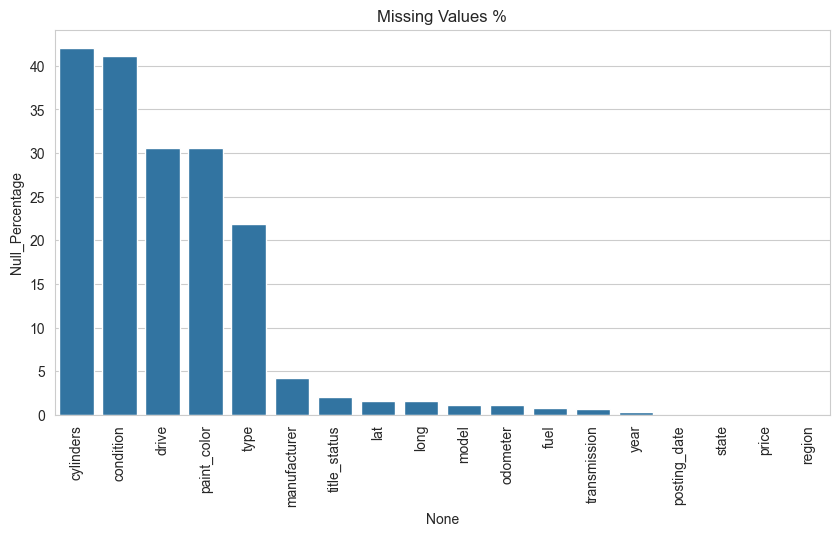

In [116]:
plt.figure(figsize=(10,5))

sns.barplot(x=null_df.index, y=null_df["Null_Percentage"]
)

plt.xticks(rotation=90)
plt.title("Missing Values %")
plt.show()

In [117]:
# Duplicate values analysis
df.duplicated().sum()

1

In [118]:
df = df.drop_duplicates()
df.shape

(49999, 18)

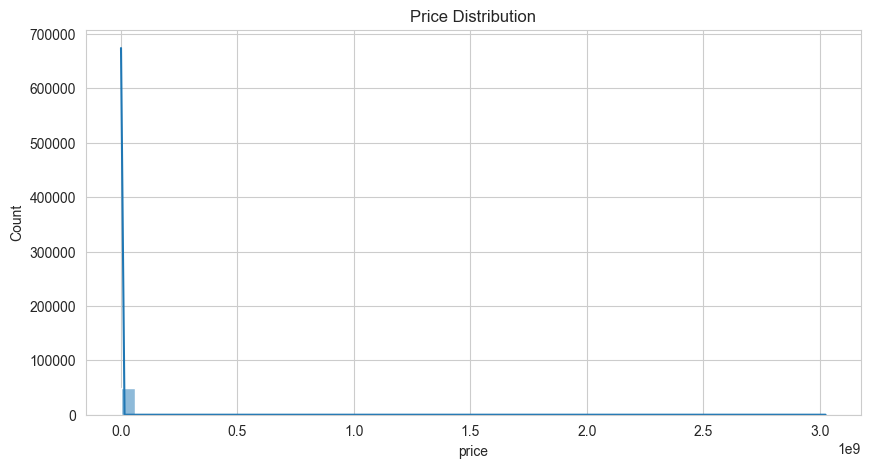

In [119]:
# Target Variable Analysis (Price)
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.show()

In [120]:
zero_count = (df['price']==0).sum()
zero_count

3835

In [121]:
# Percentage of zero values 
per_zero = round(((df['price']==0).sum()/len(df))*100, 2)
per_zero

7.67

In [122]:
df = df[df['price']>0]
df.shape

(46164, 18)

#### Since the price column is right-skewed and 7.67% of its values are zero, therefore, those rows are excluded from the dataset.

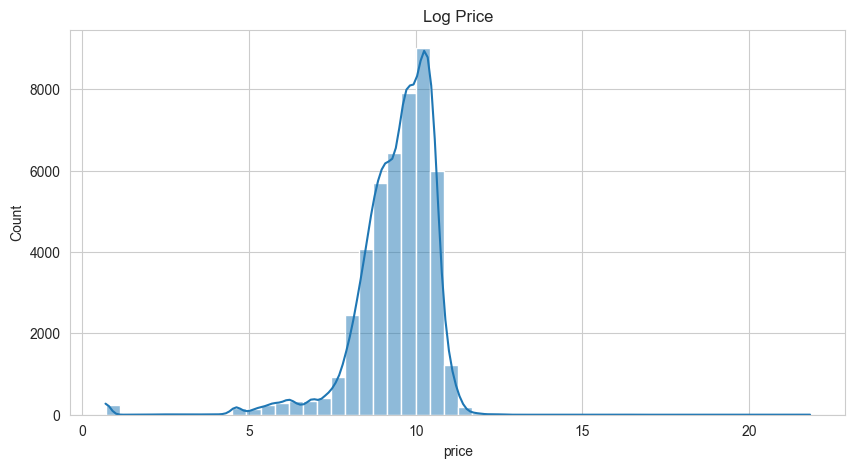

In [123]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["price"]),
    bins=50,
    kde=True
)

plt.title("Log Price")

plt.show()

In [124]:
df[df['price']>1000000000]

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,posting_date
29951,delaware,3024942282,2000.0,mercedes-benz,benz e320,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,de,39.703511,-75.746681,2021-04-20T08:46:47-0400
46543,frederick,1410065407,1989.0,jeep,wrangler,NaN,NaN,diesel,103000.0,clean,manual,NaN,SUV,NaN,md,39.441600,-77.550200,2021-04-09T16:02:34-0400


In [125]:
df["price"].describe(
    percentiles=[
        .90,
        .95,
        .99,
        .995,
        .999
    ]
)

count    4.616400e+04
mean     1.421491e+05
std      1.621770e+07
min      1.000000e+00
50%      1.522600e+04
90%      3.850000e+04
95%      4.499900e+04
99%      6.836133e+04
99.5%    7.799918e+04
99.9%    1.249992e+05
max      3.024942e+09
Name: price, dtype: float64

In [126]:
df.sort_values(
    "price",
    ascending=False
)[[
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer"
]].head(20)

,price,year,manufacturer,model,odometer
29951,3024942282,2000.0,mercedes-benz,benz e320,100000.0
46543,1410065407,1989.0,jeep,wrangler,103000.0
32545,987654321,1960.0,chevrolet,NaN,999999.0
46166,123456789,2003.0,NaN,Chevy/gmc,1234567.0
55,113456789,1980.0,bmw,NaN,100000.0
33779,12345678,2019.0,chevrolet,NaN,100000.0
4276,10004000,2002.0,ford,f350,215000.0
20336,5000000,2021.0,NaN,all,1.0
32349,1234567,1955.0,chevrolet,NaN,99999.0
40529,1000000,2022.0,NaN,Any make any model,364747.0


In [127]:
# Percentile filtering
upper = (df["price"].quantile(0.99))
lower = (df["price"].quantile(0.01))

print(f"Upper limit: {upper}")
print(f"Lower limit: {lower}")

Upper limit: 68361.33000000002
Lower limit: 142.0


In [128]:
df = df[(df["price"] >= lower)
    &
    (df["price"] <= upper)
    ]

df.shape

(45241, 18)

In [129]:
df.sort_values(
    "price",
    ascending=False
)[[
    "price",
    "year",
    "manufacturer",
    "model",
    "odometer"
]].head(20)

,price,year,manufacturer,model,odometer
15273,68358,2020.0,cadillac,escalade esv,23824.0
27441,68000,2016.0,ford,f-250,46000.0
26799,67999,2017.0,gmc,sierra duramax 2500 hd 4x4,50501.0
43766,67999,2017.0,ford,lifted f350 powerstroke,20223.0
20002,67999,2017.0,gmc,sierra diesel duramax 2500,50501.0
40349,67995,2017.0,ford,f-350,67217.0
18218,67995,2017.0,ford,f-450 super duty lariat,68700.0
14695,67995,2017.0,ford,f-450 super duty lariat,68700.0
36891,67995,2017.0,ford,f-450 super duty lariat,68700.0
15776,67995,2018.0,ford,super duty f-350 drw,61530.0


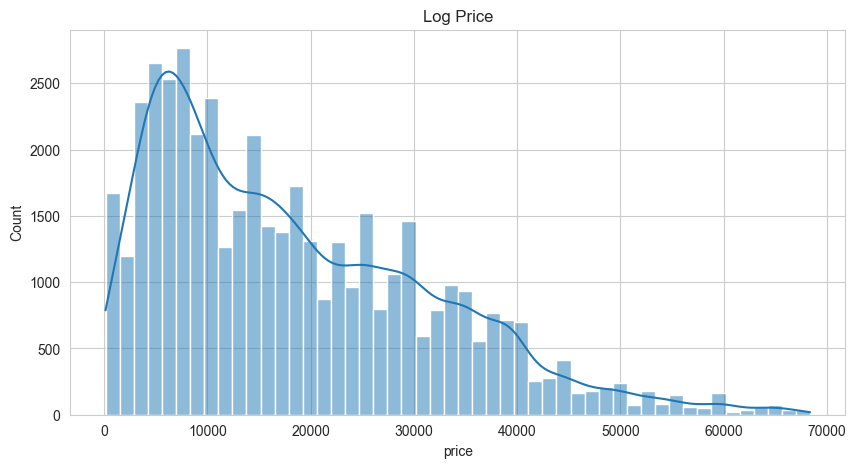

In [131]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Log Price")

plt.show()